# Trabajando con Datos ICESat-2

*En estos codigo vamos a estar trabajando en la transformación de datos *.h5 a  DataFrames, los recortaremos por nuestra área de trabajo los exportaremos a archivos *.csv y a *.shp y los guardaremos ademas por separado por Track. También visualizaremos como se ve geograficamente tus lineas de trabajo.*

Fuente de descarga: https://nsidc.org/data/data-access-tool/ATL06/versions/6  
Selecciona tu sector de trabajo y período de tiempo.  
(Recorda que te descargara la linea completa por lo que los archivos pueden pesar muchos Gigas.)

Es MUY IMPORTANTE que **no cambies** los nombres de los archivos a lo largo de los scrips porque estan pensados para funcionar así!.  
Y, **modificar** las lineas en las que dejé: # MODIFICAR  (podes hacer ctrl-F)  
(Todos códigos estan completos por si trabajas un día, cerras la compu y seguis otro.)

# 1) EXPORTAR A *.csv EL  *.h5 DESCARGADO:

Antes de todo:  
**DEDINE TU SHAPE!!!**  
Dado que la descarga es de las lineas completas, vamos a cortar el procesamiento por *areas de trabajo*. Para ello es necesario que tengas el shapefile:  
***'tu_zona_trabajo.shp'*** (en EPSG:4326)  
si no el codigo no correrá!

Además,  
**Todo lo que corras una vez con:** 
gt = 'gt1'  
**después deberías correr:** 
gt = 'gt2'  
**y con:**
gt = 'gt3'

In [ ]:
# Importamos librerias (ojo, procura tenerlas instaladas de antemano, si no las tenes --> pip install nombreDeLibreria)
import h5py
import pandas as pd
import geopandas as gpd
import os
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from shapely.geometry import Point
import rasterio
from rasterio.plot import show
import cartopy.crs as ccrs
import glob
from shapely import wkt

# Directorios:
direccion = 'C:/ICESAT-2'  # MODIFICAR
dir_descarga = f'{direccion}/carptea_descarga_ICEsat-2_NSIDC'
dir_export = f'{direccion}/exportado_ICEsat-2_NSIDC'
dir_export_shp = f'{direccion}/exportado_ICEsat-2_NSIDC_SHP'
# Crea las carpetas si no existen
os.makedirs(dir_descarga, exist_ok=True)
os.makedirs(dir_export, exist_ok=True)
os.makedirs(dir_export_shp, exist_ok=True)
# Archivos base
dir_shape = f'{direccion}/tu_zona_trabajo.shp'  # MODIFICAR
# Archivos exportados
csv_total = f'{dir_export}/ICEsat_NSICD_{gt}.csv'
cortado_csv = f'{dir_export}/ICEsat_NSICD_{gt}_recortado.csv'
cortado_shp = f'{dir_export_shp}/ICEsat_NSICD_{gt}_recortado.shp'

# Lineas a trabajar, HACER LAS 3!
gt = 'gt1' # MODIFICAR
#gt = 'gt2' # MODIFICAR
#gt = 'gt3' # MODIFICAR

# Traer lefty right para analizar cual fue la strong para cada linea
grupo_opR = f'{gt}r'
grupo_opL = f'{gt}l'


###################################################################################
#######################  Definir de funciones que usaremos  #######################
###################################################################################
def funcion_t_gps_a_year(t_gps):
    # Convertir segundos a días
    days = t_gps / (60 * 60 * 24)
    # Convertir días a años
    years = days / 365.25 # (considerando años bisiestos)
    # Sumar los años desde 1980
    decimal_year = 1980 + years
    return decimal_year
def funcion_t_year_to_datetime(decimal_year):
    # Verificar que la entrada es un número único
    if not isinstance(decimal_year, (int, float)):
        raise TypeError("decimal_year debe ser un número entero o flotante.")
    # Extraer el año entero
    year = int(decimal_year)
    # Calcular el número de días restantes en el año
    start_of_year = datetime(year, 1, 1)
    start_of_next_year = datetime(year + 1, 1, 1)
    days_in_year = (start_of_next_year - start_of_year).days
    # Extraer la fracción del año y convertirla en días
    fractional_year = decimal_year - year
    days = fractional_year * days_in_year
    # Calcular la fecha y hora
    result_date = start_of_year + timedelta(days=days)
    # Formatear la fecha en los dos formatos requeridos
    fecha_corta = result_date.strftime('%Y-%m-%d')
    return fecha_corta
# Función para procesar un archivo h5 específico y agregar datos al DataFrame total
def procesar_archivo_h5(directorio, df_total):
    nombre = os.path.splitext(os.path.basename(directorio))[0]
    # Extraer el nombre del Track
    track_field = nombre.split('_')[2]
    track_number = int(track_field[:4])  # Primeros 4 dígitos
    # Abrir el archivo HDF5
    with h5py.File(directorio, 'r') as f:
        group_name = grupo_opR
        # Extraer info
        beam_type = f[f'/{group_name}'].attrs["atlas_beam_type"].decode()
        spot_number = f[f'/{group_name}'].attrs["atlas_spot_number"].decode()
        sc_orientation = f[f'/{group_name}'].attrs["sc_orientation"].decode()
        rgt = f["/orbit_info/rgt"][:]
        t_ref = f['/ancillary_data/atlas_sdp_gps_epoch'][:]

        if beam_type == 'strong':
            group_name = group_name
        elif beam_type == 'weak':
            group_name = grupo_opL
            # Vuelvo a extraer la info
            beam_type = f[f'/{group_name}'].attrs["atlas_beam_type"].decode()
            spot_number = f[f'/{group_name}'].attrs["atlas_spot_number"].decode()
            sc_orientation = f[f'/{group_name}'].attrs["sc_orientation"].decode()
        else:
            print(f"No se que onda en {nombre}.")
            return
        # Extraer los datos de posición
        segment = f[f'{group_name}/land_ice_segments/segment_id'][:]
        longitude = f[f'{group_name}/land_ice_segments/longitude'][:]
        latitude = f[f'{group_name}/land_ice_segments/latitude'][:]
        h_li = f[f'{group_name}/land_ice_segments/h_li'][:]
        h_geo = f[f'{group_name}/land_ice_segments/dem/geoid_h'][:]
        h_li_geo = h_li - h_geo
        t_dt = f[f'{group_name}/land_ice_segments/delta_time'][:]
        t_gps = t_ref + t_dt
        t_year = funcion_t_gps_a_year(t_gps)
        # Crear DataFrame temporal para este archivo
        data = {
            'Archivo': nombre[:14],
            'segment': segment,
            'linea': group_name,
            'type': beam_type,
            'orientation': sc_orientation,
            'longitude': longitude,
            'latitude': latitude,
            'Altitude': h_li_geo,
            'time': t_year,
            'Track': track_number
        }
        df = pd.DataFrame(data)
        # Agregar al DataFrame total
        df_total = pd.concat([df_total, df], ignore_index=True)
    return df_total

###################################################################################
#################  AHORA SI, A TRABAJAR CON LOS DATOS ICESat-2:  ##################
###################################################################################
print('Archivos creados: ')
# Inicializar un DataFrame vacío
columns = ['Archivo', 'linea', 'type', 'orientation', 'segment', 'longitude', 'latitude', 'Altitude', 'time', 'Track']
df_total = pd.DataFrame(columns=columns)
# Directorio principal donde buscar los archivos h5 originales descargados
directorio_principal = dir_descarga
# Recorrer recursivamente el directorio principal y procesar archivos h5 con la funcion creada
for root, dirs, files in os.walk(directorio_principal):
    for file in files:
        if file.endswith('.h5'):
            archivo_h5 = os.path.join(root, file)
            df_total = procesar_archivo_h5(archivo_h5, df_total)
            
df_total['Date'] = df_total['time'].apply(funcion_t_year_to_datetime) # Crea columna FECHA CORTA
df_total['Date'] = pd.to_datetime(df_['Date']) # GENERA COLUMNA solo de YYYYMM para despues filtrar
df_total['YYYYMM'] = df_total['Date'].dt.strftime('%Y%m')
# Exportar todos los datos a un solo archivo CSV
df_total.to_csv(csv_total, index=False)
print(csv_total)
###################################################################################
#######  Vamos a cortar por shape de interes y exportarlo a un nuevo *.csv  #######
###################################################################################
shape_file = gpd.read_file(dir_shape)
gdf_total = gpd.GeoDataFrame(df_total, geometry=gpd.points_from_xy(df_total['longitude'], df_total['latitude']), crs='EPSG:4326')
df_cortado = gpd.clip(gdf_total, shape_file)
df_cortado.to_csv(cortado_csv, index=False) 
print(cortado_csv)

df_copia = df_cortado.copy()
##########  Podemos exportar la tabla de datos ICESat-2 a un shapefile:  ##########
df_copia['geometry'] = df_copia.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1) # Columna 'geometry' usando longitude y latitude del dataframe original
gdf_cortado = gpd.GeoDataFrame(df_copia, geometry='geometry') # Converte a GeoDataFrame
gdf_cortado.set_crs(epsg=4326, inplace=True) # Asignamos sistema de coordenadas (WGS84)
gdf_cortado.to_file(cortado_shp, driver='ESRI Shapefile')
print(cortado_shp)

df_copia_total = df_cortado.copy() # para usarlo luego si actualizamos con nuevos datos en un mismo .py
print('La tabla original cortada en nuestra zona de interés tiene: ', df_copia_total.columns)
df_copia

# Si descargamos nuevos datos...
Vamos a crear un nuevo *.csv con la nueva descarga y
# EXPORTAR A *.csv COMPLETO:

In [ ]:
# Pero qué pasa si esos datos los descargaste hace mas de medio año y posiblemente hayan nuevos datos!?
# Vamos a actualizar la tabla con nuevos datos descargados
import h5py
import pandas as pd
import geopandas as gpd
import os
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from shapely.geometry import Point
import rasterio
from rasterio.plot import show
import cartopy.crs as ccrs
import glob
from shapely import wkt

# Directorios:
direccion = 'C:/ICESAT-2'  # MODIFICAR
dir_descarga = f'{direccion}/carptea_descarga_ICEsat-2_NSIDC'
dir_actualizado = f'{direccion}/descarga_Actualizado_NSIDC'
dir_export = f'{direccion}/exportado_ICEsat-2_NSIDC'
dir_export_shp = f'{direccion}/exportado_ICEsat-2_NSIDC_SHP'
# Crea la carpetas si no existe:
os.makedirs(dir_actualizado, exist_ok=True)
# Archivos base
dir_shape = f'{direccion}/tu_zona_trabajo.shp'  # MODIFICAR
# Archivos exportados
#csv_total = f'{dir_export}/ICEsat_NSICD_{gt}.csv' # Inicial
csv_total = f'{dir_export}/ICEsat_NSICD_{gt}_actualizado.csv' # Modificado
# cortado_csv = f'{dir_export}/ICEsat_NSICD_{gt}_recortado.csv' # Inicial
cortado_csv = f'{dir_export}/ICEsat_NSICD_{gt}_actualizado_recortado.csv' # Modificado
#cortado_shp = f'{dir_export}/ICEsat_NSICD_{gt}_recortado.shp' # Inicial
cortado_shp = f'{dir_export_shp }/ICEsat_NSICD_{gt}_actualizado_recortado.shp' # Modificado
actualizado_csv = f'{dir_export}/ICEsat_NSICD_{gt}_recortado_Completo.csv'
cortado_shp_actualizado = f'{dir_export_shp }/ICEsat_NSICD_{gt}_recortado_Completo.shp'


###################################################################################
#########################  Volver a traer las funciones  ##########################
###################################################################################
def funcion_t_gps_a_year(t_gps):
    # Convertir segundos a días
    days = t_gps / (60 * 60 * 24)
    # Convertir días a años
    years = days / 365.25 # (considerando años bisiestos)
    # Sumar los años desde 1980
    decimal_year = 1980 + years
    return decimal_year
def funcion_t_year_to_datetime(decimal_year):
    # Verificar que la entrada es un número único
    if not isinstance(decimal_year, (int, float)):
        raise TypeError("decimal_year debe ser un número entero o flotante.")
    # Extraer el año entero
    year = int(decimal_year)
    # Calcular el número de días restantes en el año
    start_of_year = datetime(year, 1, 1)
    start_of_next_year = datetime(year + 1, 1, 1)
    days_in_year = (start_of_next_year - start_of_year).days
    # Extraer la fracción del año y convertirla en días
    fractional_year = decimal_year - year
    days = fractional_year * days_in_year
    # Calcular la fecha y hora
    result_date = start_of_year + timedelta(days=days)
    # Formatear la fecha en los dos formatos requeridos
    fecha_corta = result_date.strftime('%Y-%m-%d')
    return fecha_corta
# Función para procesar un archivo h5 específico y agregar datos al DataFrame total
def procesar_archivo_h5(directorio, df_total):
    nombre = os.path.splitext(os.path.basename(directorio))[0]
    # Extraer el nombre del Track
    track_field = nombre.split('_')[2]
    track_number = int(track_field[:4])  # Primeros 4 dígitos
    # Abrir el archivo HDF5
    with h5py.File(directorio, 'r') as f:
        group_name = grupo_opR
        # Extraer info
        beam_type = f[f'/{group_name}'].attrs["atlas_beam_type"].decode()
        spot_number = f[f'/{group_name}'].attrs["atlas_spot_number"].decode()
        sc_orientation = f[f'/{group_name}'].attrs["sc_orientation"].decode()
        rgt = f["/orbit_info/rgt"][:]
        t_ref = f['/ancillary_data/atlas_sdp_gps_epoch'][:]

        if beam_type == 'strong':
            group_name = group_name
        elif beam_type == 'weak':
            group_name = grupo_opL
            # Vuelvo a extraer la info
            beam_type = f[f'/{group_name}'].attrs["atlas_beam_type"].decode()
            spot_number = f[f'/{group_name}'].attrs["atlas_spot_number"].decode()
            sc_orientation = f[f'/{group_name}'].attrs["sc_orientation"].decode()
        else:
            print(f"No se que onda en {nombre}.")
            return
        # Extraer los datos de posición
        segment = f[f'{group_name}/land_ice_segments/segment_id'][:]
        longitude = f[f'{group_name}/land_ice_segments/longitude'][:]
        latitude = f[f'{group_name}/land_ice_segments/latitude'][:]
        h_li = f[f'{group_name}/land_ice_segments/h_li'][:]
        h_geo = f[f'{group_name}/land_ice_segments/dem/geoid_h'][:]
        h_li_geo = h_li - h_geo
        t_dt = f[f'{group_name}/land_ice_segments/delta_time'][:]
        t_gps = t_ref + t_dt
        t_year = funcion_t_gps_a_year(t_gps)
        # Crear DataFrame temporal para este archivo
        data = {
            'Archivo': nombre[:14],
            'segment': segment,
            'linea': group_name,
            'type': beam_type,
            'orientation': sc_orientation,
            'longitude': longitude,
            'latitude': latitude,
            'Altitude': h_li_geo,
            'time': t_year,
            'Track': track_number
        }
        df = pd.DataFrame(data)
        # Agregar al DataFrame total
        df_total = pd.concat([df_total, df], ignore_index=True)
    return df_total

###################################################################################
##################  A TRABAJAR CON LOS NEUVOS DATOS ICESat-2:  ####################
###################################################################################
# Inicializar un DataFrame vacío
columns = ['Archivo', 'linea', 'type', 'orientation', 'longitude', 'latitude', 'Altitude', 'time', 'Track']
df_total = pd.DataFrame(columns=columns)
directorio_principal = dir_actualizado
# Recorrer recursivamente el directorio principal y procesar archivos h5
for root, dirs, files in os.walk(directorio_principal):
    for file in files:
        if file.endswith('.h5'):
            archivo_h5 = os.path.join(root, file)
            df_total = procesar_archivo_h5(archivo_h5, df_total)

df_total['Date'] = df_total['time'].apply(funcion_t_year_to_datetime) # Crea columna FECHA CORTA
df_total['Date'] = pd.to_datetime(df_total['Date'], errors='coerce') # GENERA COLUMNA solo de YYYYMM para despues filtrar
df_total['YYYYMM'] = df_total['Date'].dt.strftime('%Y-%m')
# Exportar todos los datos a un solo archivo CSV
df_total.to_csv(csv_total, index=False)
print(df_total)

#  Cortar por el MISMO shapede interes y exportarlo a un nuevo *.csv 
shape_file = gpd.read_file(dir_shape)
gdf = gpd.GeoDataFrame(df_total, geometry=gpd.points_from_xy(df_total['longitude'], df_total['latitude']), crs='EPSG:4326')
df_cortado = gpd.clip(gdf, shape_file)
df_cortado.to_csv(cortado_csv, index=False)
print(cortado_csv)

df_copia = df_cortado.copy()
df_copia['geometry'] = df_copia.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1) # Crear la columna 'geometry' usando longitude y latitude
gdf_cortado = gpd.GeoDataFrame(df_copia, geometry='geometry') # Convertirlo a GeoDataFrame
gdf_cortado.set_crs(epsg=4326, inplace=True) # Asignar sistema de coordenadas (WGS84)
gdf_cortado.to_file(cortado_shp, driver='ESRI Shapefile')
df_copia = df_cortado.copy() # para que la tabla df_copia no tenga la columna geometry que recién creamos para el shape
print(cortado_shp)

###################################################################################
##################### AHORA SI, UNIR LOS DATOS ICESat-2: ##########################
###################################################################################
# Cargar los archivos CSV
df_actual = pd.read_csv(f'{dir_export}/ICEsat_NSICD_{gt}_actualizado_recortado.csv') # o se podría cargar: df_actual = df_cortado.copy()
df_total = pd.read_csv(f'{dir_export}/ICEsat_NSICD_{gt}_recortado.csv') # Si trabajaste todo en este codigo, podrías cargar: df_total = df_copia_total.copy()
# Combinar los DataFrames
df_totalmasactual = pd.concat([df_total, df_actual], ignore_index=True).drop_duplicates()
# EXPORTAR EL DF COMPLETO Y ACTUALIZADO
df_totalmasactual.to_csv(actualizado_csv, index=False)
print(actualizado_csv)
# A shapefile
df_actualizado = df_totalmasactual.copy()
df_actualizado['geometry'] = df_actualizado.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
gdf_cortado = gpd.GeoDataFrame(df_actualizado, geometry='geometry')
gdf_cortado.set_crs(epsg=4326, inplace=True)
gdf_cortado.to_file(cortado_shp_actualizado, driver='ESRI Shapefile')
print(cortado_shp_actualizado)

print('La tabla original cortada en nuestra zona de interés tiene: ', df_totalmasactual.columns)
df_totalmasactual

# CORTAR EL CSV COMPLETO POR LINEAS/TRACK

# Opción 1:
Antes, crea **'shapes_corte_{gtX}.shp'** con polígonos de diferente **ID**s que abarquen toda el area que atraviesa cada Track  
(para ello te recomiendo abras el *'cortado_shp_actualizado'* o *'cortado_shp'* en un visor)

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import glob
import os

# Linea a trabajar
gt = 'gt1' # MODIFICAR
#gt = 'gt2' # MODIFICAR
#gt = 'gt3' # MODIFICAR

direccion = 'C:/ICESAT-2' # MODIFICAR
dir_export = f'{direccion}/exportado_ICEsat-2_NSIDC'
csv_actualizado = f'{dir_export}/ICEsat_NSICD_{gt}_recortado_Completo.csv'
csv_original = f'{dir_export}/ICEsat_NSICD_{gt}_recortado.csv'
shape_cortes = f'{direccion}/shapes_cortes/shapes_corte_{gt}.shp' # MODIFICAR lo deberías crear/tener con Atributo 'ID' de valores unicos
carpeta_corte = f'{direccion}/LineasID_ICEsat-2_NSIDC_recortados_{gt}/' 
# Crea la carpeta que no existe
os.makedirs(carpeta_corte, exist_ok=True)


######################################################################################################
#####################################  ABRIR archivos a usar  ########################################
######################################################################################################
if os.path.exists(csv_actualizado): # Abrir el csv actualizado
    df = pd.read_csv(csv_actualizado)
    print(f'Se abrió: {csv_actualizado}')
elif os.path.exists(csv_original): # Pero si no actualizaste
    df = pd.read_csv(csv_original)
    print(f'Se abrió: {csv_original}')
else: # Si hay algún error
    raise FileNotFoundError("Ninguno de los archivos existe.")

df = pd.read_csv(lineas_gt)
gdf_points = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']), crs='EPSG:4326') # asignar WGS84

shape_corte = gpd.read_file(shape_cortes)

# Iterar en cada polígono del shapefile de poligonos de areas que abarcan los tracks:
for _, polygon in shape_corte.iterrows():
    id_poligono = polygon['id'] # MODIFICAR si es que en tu shape creado a mano el atributo tiene otro nombre
    # Filtrar puntos dentro del polígono
    puntos_dentro = gdf_points[gdf_points.within(polygon['geometry'])]
    # Asignar el track_id correspondiente
    puntos_dentro['track_id'] = id_poligono
    # Guardar el resultado en un CSV
    output_file = f'{carpeta_corte}/ICEsat_NSICD_{gt}_recortado_linea_{id_poligono}.csv' # Ó f'{carpeta_corte}/ICEsat_NSICD_{gt}_recortado__cOMPLETO{id_poligono}.csv.shp' SI LO ACTUALIZASTE
    puntos_dentro.to_csv(output_file, index=False)
print("Proceso de corte completo y CSVs guardados por id_poligono.")

# Opcion 2a (recomendada)
Trabajar por track.
### Exportar todos los tracks:

In [ ]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import glob

# Linea a trabajar
gt = 'gt1' # MODIFICAR
#gt = 'gt2' # MODIFICAR
#gt = 'gt3' # MODIFICAR

# Directorios:
direccion = 'C:/ICESAT-2'  # MODIFICAR
#dir_descarga = f'{direccion}/carptea_descarga_ICEsat-2_NSIDC' # ya no necesito
#dir_actualizado = f'{direccion}/descarga_Actualizado_NSIDC' # ya no necesito
dir_export = f'{direccion}/exportado_ICEsat-2_NSIDC'
#dir_export_shp = f'{direccion}/exportado_ICEsat-2_NSIDC_SHP' # ya no necesito
dir_export_tracks = f'{direccion}/Tracks_ICEsat-2_NSIDC_recortados_{gt}'
# Archivos base
dir_shape = f'{direccion}/tu_zona_trabajo.shp'  # MODIFICAR
dir_raster = f'{direccion}/tu_Landsat8_EPSG4326.tif' # MODIFICAR
# Archivos exportados anteriormente
csv_actualizado = f'{dir_export}/ICEsat_NSICD_{gt}_recortado_Completo.csv'
csv_original = f'{dir_export}/ICEsat_NSICD_{gt}_recortado.csv'
# Crea la carpeta que no existe
os.makedirs(dir_export_tracks, exist_ok=True)


######################################################################################################
#####################################  ABRIR archivos a usar  ########################################
######################################################################################################
if os.path.exists(csv_actualizado): # Abrir el csv actualizado
    df = pd.read_csv(csv_actualizado)
    print(f'Se abrió: {csv_actualizado}')
elif os.path.exists(csv_original): # Pero si no actualizaste
    df = pd.read_csv(csv_original)
    print(f'Se abrió: {csv_original}')
else: # Si hay algún error
    raise FileNotFoundError("Ninguno de los archivos existe.")
shape_file = gpd.read_file(dir_shape)
print('Shape límite: ' , dir_shape)
raster_file = rasterio.open(dir_raster)
print('Imagen Base: ' , dir_raster)

######################################################################################################
######### crear y exportar cantidad de tablas por cantidad de tracks que existan en la tabla #########
######################################################################################################
tracks_unicos = df['Track'].unique()
dfs_por_track = {}
nombres_dfs = []
os.makedirs(dir_export_tracks, exist_ok=True) # Asegura que la carpeta exista
for track in tracks_unicos: # Recorrer los Tracks únicos
    nombre_variable = f'df_{track}'
    df_track = df[df['Track'] == track].copy()
    dfs_por_track[nombre_variable] = df_track # Guardao en el diccionario
    nombres_dfs.append(nombre_variable) # Guarda el nombre creado en la lista
    # Exportar a CSV:
    nombre_CSVs = f'{dir_export_tracks}/ICEsat_NSICD_{gt}_Track_{track}.csv'
    df_track.to_csv(nombre_CSVs, index=False)
print('Se crearon los csv para cada Track en la carpeta: ', dir_export_track)
# No exportamos a shapes los track porque ya tenemos el shape completo cortado con todos los tracks
# En el siguiente codigo dejo unas lineas para exportar por track a elección
    
######################################################################################################
#####################  Ver tabla de Track y cantidad de registros por cada Track  ####################
######################################################################################################
tabla_tracks = df['Track'].value_counts().reset_index()
tabla_tracks.columns = ['Track', 'Cantidad_Registros']
tabla_tracks = tabla_tracks.sort_values('Track').reset_index(drop=True) # Ordena por Track
print(tabla_tracks)

### Plotear los tracks:

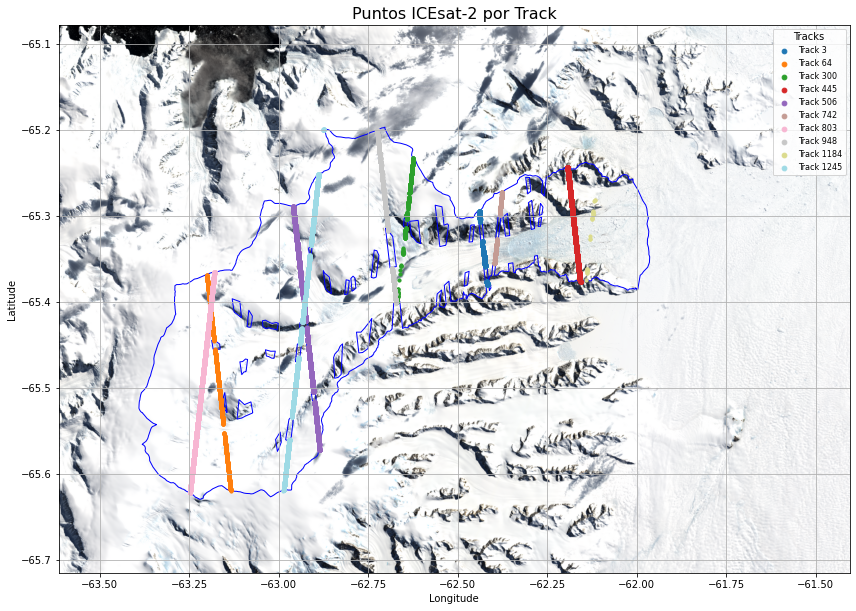

   Track  Cantidad_Registros
0      3                 482
1     64                1175
2    300                 461
3    445                2226
4    506                3243
5    742                 635
6    803                5451
7    948                1827
8   1184                  31
9   1245                4018


In [6]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import glob

# Linea a trabajar
gt = 'gt1' # MODIFICAR
#gt = 'gt2' # MODIFICAR
#gt = 'gt3' # MODIFICAR

# Directorios:
direccion = 'C:/ICESAT-2'  # MODIFICAR
#dir_descarga = f'{direccion}/carptea_descarga_ICEsat-2_NSIDC' # ya no necesito
#dir_actualizado = f'{direccion}/descarga_Actualizado_NSIDC' # ya no necesito
dir_export = f'{direccion}/exportado_ICEsat-2_NSIDC'
#dir_export_shp = f'{direccion}/exportado_ICEsat-2_NSIDC_SHP' # ya no necesito
# dir_export_tracks = f'{direccion}/Tracks_ICEsat-2_NSIDC_recortados_{gt}' # no se necesita para el ploteo
# Archivos base
dir_shape = f'{direccion}/tu_zona_trabajo.shp'  # MODIFICAR
dir_raster = f'{direccion}/tu_Landsat8_EPSG4326.tif' # MODIFICAR
# Archivos exportados anteriormente
csv_actualizado = f'{dir_export}/ICEsat_NSICD_{gt}_recortado_Completo.csv'
csv_original = f'{dir_export}/ICEsat_NSICD_{gt}_recortado.csv'
# Crea la carpeta que no existe
os.makedirs(dir_export_tracks, exist_ok=True)


######################################################################################################
#####################################  ABRIR archivos a usar  ########################################
######################################################################################################
if os.path.exists(csv_actualizado): # Abrir el csv actualizado
    df = pd.read_csv(csv_actualizado)
    print(f'Se abrió: {csv_actualizado}')
elif os.path.exists(csv_original): # Pero si no actualizaste
    df = pd.read_csv(csv_original)
    print(f'Se abrió: {csv_original}')
else: # Si hay algún error
    raise FileNotFoundError("Ninguno de los archivos existe.")
shape_file = gpd.read_file(dir_shape)
print('Shape límite: ' , dir_shape)
raster_file = rasterio.open(dir_raster)
print('Imagen Base: ' , dir_raster)

    
######################################################################################################
###########################  PLOTEAR todos tracks que existan en la tabla  ###########################
######################################################################################################
fig, ax = plt.subplots(figsize=(12, 10)) # CREAA FIGURA
# Mostrar el raster
show(raster_file, ax=ax)
# Mostrar el shapefile encima
shape_file.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1, label='Glaciares')
# Convertir el df a un GeoDataFrame para poder plotear
gdf_puntos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)
# Asignar un color único para cada Track
tracks_unicos = gdf_puntos['Track'].unique()
tracks_unicos.sort()
# Crear un mapa de colores
cmap = plt.get_cmap('tab20', len(tracks_unicos)) 
colors = {track: cmap(i) for i, track in enumerate(tracks_unicos)}
# Plotear los puntos con diferentes colores por Track
for track, color in colors.items():
    subset = gdf_puntos[gdf_puntos['Track'] == track]
    subset.plot(ax=ax, markersize=10, color=color, label=f'Track {track}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Puntos ICEsat-2 por Track', fontsize=16)
ax.legend(title='Tracks', loc='best', markerscale=1.5, fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()

######################################################################################################
#####################  Ver tabla de Track y cantidad de registros por cada Track  ####################
######################################################################################################
tabla_tracks = df['Track'].value_counts().reset_index()
tabla_tracks.columns = ['Track', 'Cantidad_Registros']
tabla_tracks = tabla_tracks.sort_values('Track').reset_index(drop=True) # Ordena por Track
print(tabla_tracks)

# Opcion 2b
Trabajar por track.
### Exportar Track de interés

In [ ]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import glob

# Linea a trabajar
gt = 'gt1' # MODIFICAR
#gt = 'gt2' # MODIFICAR
#gt = 'gt3' # MODIFICAR

# Directorios:
direccion = 'C:/ICESAT-2'  # MODIFICAR
#dir_descarga = f'{direccion}/carptea_descarga_ICEsat-2_NSIDC' # ya no necesito
#dir_actualizado = f'{direccion}/descarga_Actualizado_NSIDC' # ya no necesito
dir_export = f'{direccion}/exportado_ICEsat-2_NSIDC'
#dir_export_shp = f'{direccion}/exportado_ICEsat-2_NSIDC_SHP' # ya no necesito
dir_export_tracks = f'{direccion}/Tracks_ICEsat-2_NSIDC_recortados_{gt}'
# Archivos base
dir_shape = f'{direccion}/tu_zona_trabajo.shp'  # MODIFICAR
dir_raster = f'{direccion}/tu_Landsat8_EPSG4326.tif' # MODIFICAR
# Archivos exportados anteriormente
csv_actualizado = f'{dir_export}/ICEsat_NSICD_{gt}_recortado_Completo.csv'
csv_original = f'{dir_export}/ICEsat_NSICD_{gt}_recortado.csv'
# Crea la carpeta si no existe
os.makedirs(dir_export_tracks, exist_ok=True)


######################################################################################################
#####################################  ABRIR archivos a usar  ########################################
######################################################################################################
if os.path.exists(csv_actualizado): # Abrir el csv actualizado
    df = pd.read_csv(csv_actualizado)
    print(f'Se abrió: {csv_actualizado}')
elif os.path.exists(csv_original): # Pero si no actualizaste
    df = pd.read_csv(csv_original)
    print(f'Se abrió: {csv_original}')
else: # Si hay algún error
    raise FileNotFoundError("Ninguno de los archivos existe.")
shape_file = gpd.read_file(dir_shape)
print('Shape límite: ' , dir_shape)
raster_file = rasterio.open(dir_raster)
print('Imagen Base: ' , dir_raster)

######################################################################################################
##########################  SOLO exportar tablas por TRACK DE INTERES  ###############################
######################################################################################################
id_track = 3 # MODIFICAR

df_filtrado = df[df['Track'] == id_track] 
# pueden convertir a string si no sabes si es entero o cadena: 
#df_filtrado = df[df['Track'].astype(str) == str(id_track)]
csv_filtrado = f'{dir_export_tracks}/ICEsat_NSICD_{gt}_Track_{id_track}.csv'
df_filtrado.to_csv(csv_filtrado, index=False)
print('Se creó el csv para el Track de interes: ', csv_filtrado)
# Puede exportar tu track a shape:
df_copia = df_filtrado.copy()
df_copia['geometry'] = df_copia.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1) # Crear la columna 'geometry' usando longitude y latitude
gdf_track = gpd.GeoDataFrame(df_copia, geometry='geometry') # Convertirlo a GeoDataFrame
gdf_track.set_crs(epsg=4326, inplace=True) # Asignar sistema de coordenadas (WGS84)
track_cortado_shp = f'{dir_export_tracks}/ICEsat_NSICD_{gt}_Track_{id_track}.shp'
gdf_track.to_file(track_cortado_shp, driver='ESRI Shapefile')
print(track_cortado_shp)
    
    
#####################################################################################################
#######################################  PLOTEAR el track  ##########################################
#####################################################################################################
fig, ax = plt.subplots(figsize=(12, 10))  # CREA FIGURA
# Mostrar el raster
show(raster_file, ax=ax)
# Mostrar el shapefile encima
shape_file.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1, label='Glaciares')
# Convertir el df a un GeoDataFrame para poder plotear
gdf_puntos = gpd.GeoDataFrame(
    df_copia,
    geometry=gpd.points_from_xy(df_copia['longitude'], df_copia['latitude']),
    crs='EPSG:4326'
)
# Plotear todo el Track
gdf_puntos.plot(ax=ax, markersize=10, color='red', label='Puntos ICEsat-2')  # Cambia 'red' por el color que prefieras
# Dar parametros
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Puntos ICEsat-2', fontsize=16)
ax.legend(loc='best', markerscale=1.5, fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()


######################################################################################################
#######################################  Ver tabla del Track  ########################################
######################################################################################################
df_filtrado